In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

df = pd.read_csv("bank-full.csv", sep=';')

def clean_bank_marketing_data(df):
    if 'duration' in df.columns:
        df = df.drop(columns=['duration'])
    
    df['was_never_contacted'] = (df['pdays'] == -1).astype(int)
    
    df['y'] = df['y'].map({'yes': 1, 'no': 0})
    
    return df

df_cleaned = clean_bank_marketing_data(df)

numeric_features = ['age', 'balance', 'day', 'pdays', 'previous', 'campaign']
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

X = df_cleaned.drop('y', axis=1)
y = df_cleaned['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

cat_columns = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
feature_names = numeric_features + cat_columns + ['was_never_contacted']

X_train_final = pd.DataFrame(X_train_transformed, columns=feature_names)
X_test_final = pd.DataFrame(X_test_transformed, columns=feature_names)

print(f"Training set size: {X_train_final.shape}")
print(f"Testing set size: {X_test_final.shape}")
print(X_train_final.head())

Training set size: (36168, 51)
Testing set size: (9043, 51)
        age   balance       day     pdays  previous  campaign  job_admin.  \
0 -0.460434 -0.164410  1.582124 -0.410910 -0.241509 -0.246104         0.0   
1 -1.589641  0.899627 -1.298384  1.446096  2.664584  0.398202         0.0   
2  0.292371 -0.365486 -0.458236 -0.410910 -0.241509  0.398202         0.0   
3  0.668773 -0.445003  1.822166 -0.410910 -0.241509  2.653271         0.0   
4 -0.272233 -0.361249  1.222060 -0.410910 -0.241509  2.331118         0.0   

   job_blue-collar  job_entrepreneur  job_housemaid  ...  month_mar  \
0              0.0               0.0            0.0  ...        0.0   
1              0.0               0.0            0.0  ...        0.0   
2              0.0               0.0            0.0  ...        0.0   
3              0.0               0.0            0.0  ...        0.0   
4              0.0               0.0            0.0  ...        0.0   

   month_may  month_nov  month_oct  month_sep  pou

In [2]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_final, y_train)

print(f"Original class distribution: {Counter(y_train)}")
print(f"Balanced class distribution: {Counter(y_train_balanced)}")


Original class distribution: Counter({0: 31937, 1: 4231})
Balanced class distribution: Counter({0: 31937, 1: 31937})


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'newton-cg'}

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.75      0.83      7985
           1       0.25      0.65      0.36      1058

    accuracy                           0.74      9043
   macro avg       0.60      0.70      0.60      9043
weighted avg       0.86      0.74      0.78      9043


Confusion Matrix:


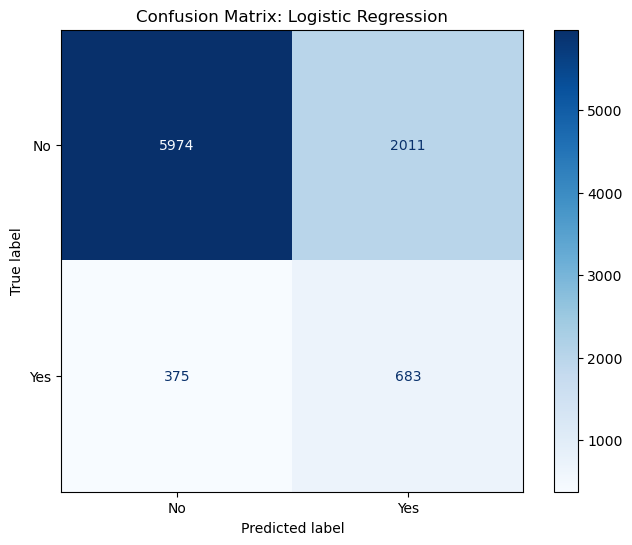

In [3]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'newton-cg'],
    'class_weight': ['balanced', None]
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_grid_lr,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train_balanced, y_train_balanced)

best_lr_balanced = lr_grid.best_estimator_

print(f"Best Parameters: {lr_grid.best_params_}")
y_pred_lr = best_lr_balanced.predict(X_test_final)

# Print Text Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# Generate and Plot Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best RF Parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 200}

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.94      7985
           1       0.51      0.32      0.39      1058

    accuracy                           0.88      9043
   macro avg       0.71      0.64      0.66      9043
weighted avg       0.87      0.88      0.87      9043


Confusion Matrix:


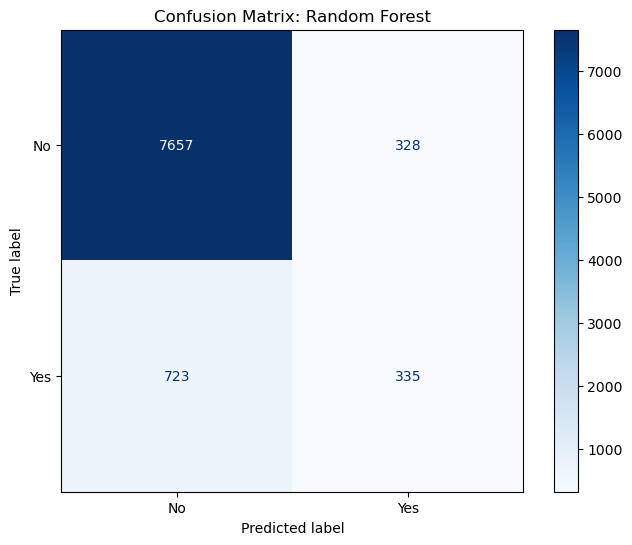

In [4]:
from sklearn.ensemble import RandomForestClassifier

# 1. Define the parameter grid
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# 2. Initialize GridSearch with 5-fold CV
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# 3. Fit using the BALANCED training data
rf_grid.fit(X_train_balanced, y_train_balanced)

# 4. Extract the best model
best_rf = rf_grid.best_estimator_
print(f"Best RF Parameters: {rf_grid.best_params_}")

# 5. Predict on the ORIGINAL Test Set
y_pred_rf = best_rf.predict(X_test_final)

# 6. Confusion Matrix

# Print Text Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Generate and Plot Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Random Forest')
plt.show()

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [13:19:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [13:19:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [13:19:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [13:19:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iterati


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7985
           1       0.60      0.30      0.40      1058

    accuracy                           0.89      9043
   macro avg       0.76      0.64      0.67      9043
weighted avg       0.88      0.89      0.88      9043


Confusion Matrix:


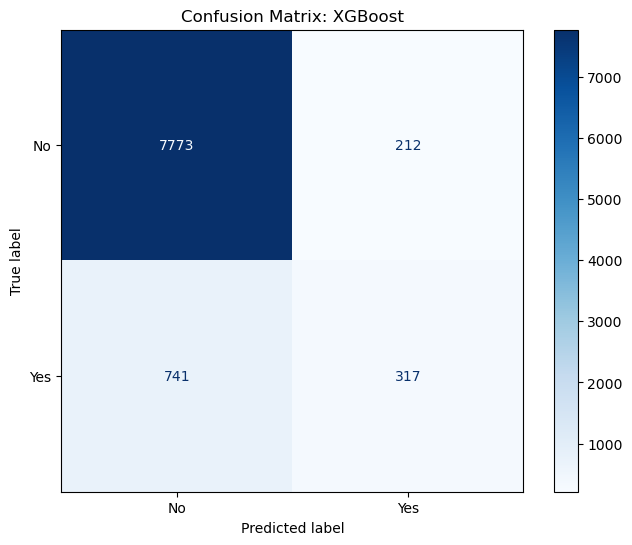

In [5]:
from xgboost import XGBClassifier

ratio = (y_train_balanced == 0).sum() / (y_train_balanced == 1).sum()

param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7],
    'scale_pos_weight': [ratio] 
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_grid=param_grid_xgb,
    scoring='f1',
    cv=5,
    n_jobs=-1, 
    verbose=1
)

xgb_grid.fit(X_train_balanced, y_train_balanced)

best_xgb = xgb_grid.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_final)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: XGBoost')
plt.show()

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Parameters: {'C': 0.01, 'class_weight': 'balanced', 'max_iter': 2000}

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.76      0.84      7985
           1       0.26      0.63      0.37      1058

    accuracy                           0.75      9043
   macro avg       0.60      0.69      0.60      9043
weighted avg       0.86      0.75      0.79      9043



<Figure size 800x600 with 0 Axes>

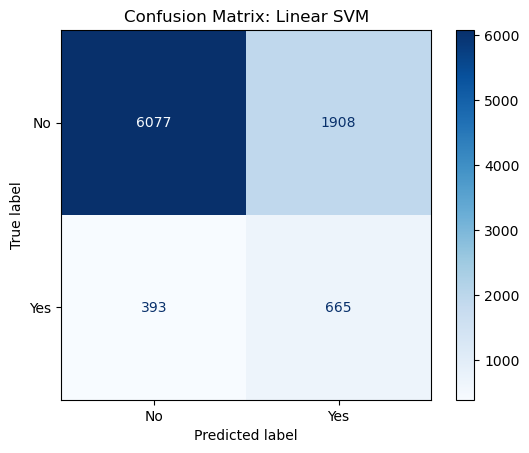

In [6]:
from sklearn.svm import LinearSVC

param_grid_svm = {
    'C': [0.01, 0.1, 1, 10],
    'class_weight': ['balanced'],
    'max_iter': [2000]
}

svm_grid = GridSearchCV(
    estimator=LinearSVC(random_state=42, dual=False),
    param_grid=param_grid_svm,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train_balanced, y_train_balanced)

best_svm = svm_grid.best_estimator_

print(f"Best Parameters: {svm_grid.best_params_}")

y_pred_svm = best_svm.predict(X_test_final)

print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Linear SVM')
plt.grid(False)
plt.show()

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (64, 32), 'learning_rate': 'constant', 'solver': 'adam'}

Neural Network Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.83      0.87      7985
           1       0.26      0.47      0.34      1058

    accuracy                           0.78      9043
   macro avg       0.59      0.65      0.60      9043
weighted avg       0.84      0.78      0.81      9043



/opt/miniconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:788: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


<Figure size 800x600 with 0 Axes>

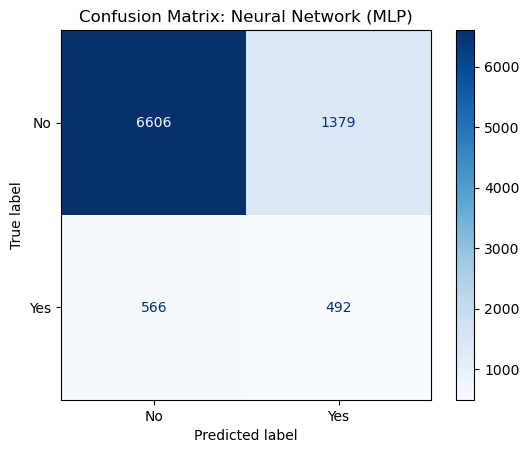

In [9]:
from sklearn.neural_network import MLPClassifier

param_grid_mlp = {
    'hidden_layer_sizes': [(64, 32), (100,)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.05],
    'learning_rate': ['constant', 'adaptive'],
}

mlp_grid = GridSearchCV(
    estimator=MLPClassifier(max_iter=1000, random_state=42),
    param_grid=param_grid_mlp,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

mlp_grid.fit(X_train_balanced, y_train_balanced)

best_mlp = mlp_grid.best_estimator_

print(f"Best Parameters: {mlp_grid.best_params_}")

y_pred_mlp = best_mlp.predict(X_test_final)

print("\nNeural Network Classification Report:")
print(classification_report(y_test, y_pred_mlp))

cm = confusion_matrix(y_test, y_pred_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Neural Network (MLP)')
plt.grid(False)
plt.show()

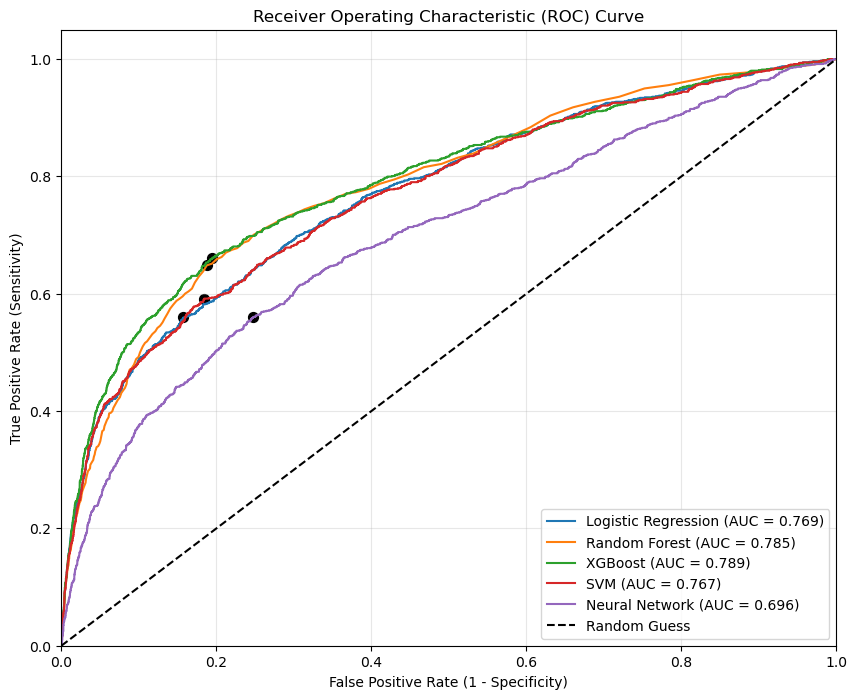


Optimal Thresholds and Metrics:
                          AUC  Best Threshold  Sensitivity  Specificity
Logistic Regression  0.769414        0.554215     0.559546     0.842580
Random Forest        0.784509        0.225000     0.648393     0.812398
XGBoost              0.789152        0.175540     0.661626     0.805135
SVM                  0.767256        0.613261     0.591682     0.815780
Neural Network       0.695956        0.306665     0.560491     0.752286


In [10]:
from sklearn.metrics import roc_curve, auc, brier_score_loss
import matplotlib.pyplot as plt

def plot_roc_and_find_cutoff(models, X_test, y_test):
    plt.figure(figsize=(10, 8))
    
    results = {}
    
    for name, model in models.items():
        # Get predicted probabilities for the positive class
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        else: # For models like LinearSVC that don't have predict_proba by default
            y_prob = model.decision_function(X_test)
            # Scale to 0-1 range
            y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())

        fpr, tpr, thresholds = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        
        # Calculate Youden's J Statistic: J = TPR - FPR
        j_scores = tpr - fpr
        best_idx = j_scores.argmax()
        best_threshold = thresholds[best_idx]
        
        results[name] = {
            "AUC": roc_auc,
            "Best Threshold": best_threshold,
            "Sensitivity": tpr[best_idx],
            "Specificity": 1 - fpr[best_idx]
        }
        
        # Plot the curve
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')
        # Mark the optimal cutoff point
        plt.scatter(fpr[best_idx], tpr[best_idx], marker='o', color='black', s=50)

    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    
    return results

# Dictionary of your trained models
trained_models = {
    "Logistic Regression": best_lr_balanced,
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
    "SVM": best_svm,
    "Neural Network": best_mlp
}

# Run the optimization
optimization_results = plot_roc_and_find_cutoff(trained_models, X_test_final, y_test)

# Display the optimal cutoffs
import pandas as pd
df_results = pd.DataFrame(optimization_results).T
print("\nOptimal Thresholds and Metrics:")
print(df_results)